# NBA Player Performance Forecasting Using Machine Learning
## Project Goal

This project investigates whether historical NBA player statistics can be used to predict future scoring performance. Using data collected from the NBA API across multiple seasons, machine learning models were developed to estimate a player's next-season Points Per Game (PPG).

The project follows a complete data sceince workflow including data collection, preprocessing, feature engineering, model development, performance evaluation, and error analysis. Multiple predictive appraoches were compared to determine which factors are most important for forecasting future scoring production and to identify situations where player performance exceeds or falls short of model expectations.

In [484]:
from nba_api.stats.endpoints import LeagueDashPlayerStats
import pandas as pd

In [485]:
stats = LeagueDashPlayerStats(season='2024-25')
df = stats.get_data_frames()[0]
df

,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,...,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,TEAM_COUNT
0,1630639,A.J. Lawson,A.J.,1610612761,TOR,24.0,26,14,12,0.538,...,241,200,327,337,299,375,159,44,364,1
1,1631260,AJ Green,AJ,1610612749,MIL,25.0,73,44,29,0.603,...,99,498,290,214,62,247,281,44,225,1
2,1642358,AJ Johnson,AJ,1610612764,WAS,20.0,29,8,21,0.276,...,312,217,369,347,495,379,281,44,372,2
3,203932,Aaron Gordon,Aaron,1610612743,DEN,29.0,51,33,18,0.647,...,451,301,107,139,41,183,134,44,181,1
4,1628988,Aaron Holiday,Aaron,1610612745,HOU,28.0,62,39,23,0.629,...,224,259,292,292,115,322,281,44,315,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,203897,Zach LaVine,Zach,1610612758,SAC,30.0,74,32,42,0.432,...,501,418,46,12,414,40,93,44,23,2
565,1630192,Zeke Nnaji,Zeke,1610612743,DEN,24.0,57,36,21,0.632,...,254,252,327,365,323,343,281,44,357,1
566,1630533,Ziaire Williams,Ziaire,1610612751,BKN,23.0,63,22,41,0.349,...,458,476,142,178,551,189,159,44,184,1
567,1629627,Zion Williamson,Zion,1610612740,NOP,24.0,30,10,20,0.333,...,536,301,80,141,369,180,77,15,190,1


## Data Collection

The NBA API was used to retreive player statistics for the 2024-25 season. The dataset contains information for every NBA player, including age, games played, minutes, points, rebounds, assists, and shooting percentages.

This data serves as the foundation for the analysis and model developement.

In [486]:
df[["PLAYER_NAME", "PTS"]].sort_values(by = "PTS", ascending = False).head()

,PLAYER_NAME,PTS
490,Shai Gilgeous-Alexander,2484
29,Anthony Edwards,2177
423,Nikola Jokić,2071
180,Giannis Antetokounmpo,2036
263,Jayson Tatum,1932


## Exploring the Dataset

Before building any machine learning modesl, the data was inspected to understand its structure and identify key statistics.

The highest-scoring players in the league were examined to verify that the dataset was loaded correctly and to gain familiarity with the data.

In [487]:
import matplotlib.pyplot as plt

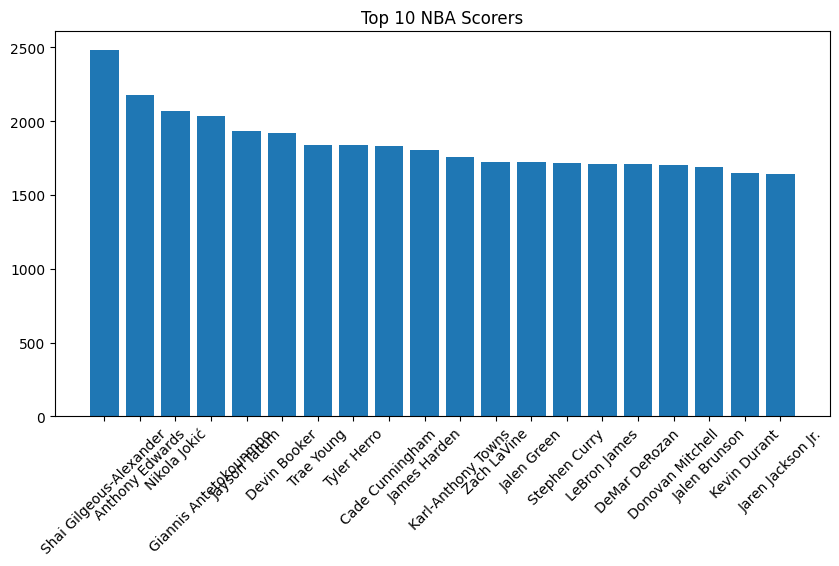

In [488]:
t10 = df[["PLAYER_NAME", "PTS"]].sort_values(by = "PTS", ascending = False).head(20)
plt.figure(figsize = (10, 5))
plt.bar(t10["PLAYER_NAME"], t10["PTS"])
plt.xticks(rotation = 45)
plt.title("Top 10 NBA Scorers")
plt.show()

## Top NBA Scorers

The chart above displays the highest total point scorers in the NBA.

SGA led the league in total points, followed by Anthony Edwards, Nikola Jokic, and Giannis Antetokoumpo.

This visualization provides a quick overview of offensive production across the league.

In [489]:
seasons = ["2020-21", "2021-22", "2022-23", "2023-24", "2024-25"]

all_data = []

for season in seasons:
    print(f"Downloading {season}")
    stats = LeagueDashPlayerStats(season=season)
    season_df = stats.get_data_frames()[0]
    season_df["SEASON"] = season
    all_data.append(season_df)

In [490]:
master = pd.concat(all_data, ignore_index=True)
master.shape
master.to_csv("../data.nba_stats.csv", index = False)

## Creating a Historical Dataset

To predict future performance, data from multiple NBA seasons was collected and combined into a single dataset.

Using multiple seasons allows the model to learn trends in player development rather than relying on only one year of information.

In [491]:
master.columns.to_list
master = master.sort_values(["PLAYER_ID", "SEASON"])
master["NEXT_PTS"] = (master.groupby("PLAYER_ID")["PTS"].shift(-1))

#remove nulls
master = master.dropna(subset=["NEXT_PTS"])

#remove players that played almost no minutes
master = master[master["MIN"] > 1000]

master[['PLAYER_NAME','SEASON','PTS','NEXT_PTS']].head()


,PLAYER_NAME,SEASON,PTS,NEXT_PTS
333,LeBron James,2020-21,1126,1695.0
914,LeBron James,2021-22,1695,1590.0
1477,LeBron James,2022-23,1590,1822.0
2048,LeBron James,2023-24,1822,1710.0
66,Carmelo Anthony,2020-21,924,919.0


## Initial Prediction Target: Next Season Total Points

The original goal of the project was to predict a player's total points scored during the following NBA season.

To create this target variable, each player's total points (PTS) were matched with their total points from the next season using the player's unique identifier.

This produced a new variable, NEXT_PTS, which respresented future scoring production and served as the initial predicition target.

In [492]:
master["AGE_SQUARED"] = master["AGE"] ** 2
features = ["AGE", "AGE_SQUARED", "PTS", "AST", "REB", "MIN"]

X = master[features]
y = master["NEXT_PTS"]

X.head()
y.head()

333     1695.0
914     1590.0
1477    1822.0
2048    1710.0
66       919.0
Name: NEXT_PTS, dtype: float64

In [493]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[-35.32, 0.36, 0.95, 0.25, 0.1 , -0.15]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['AGE','AGE_SQUARED','PTS','AST','REB','MIN']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,846.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6


### Train-Test Split

Before training the models, the dataset was divided into training and testng subsets using an 80/20 split.

The training set is used to teach the model relationships between player statistics and future scoring performance, while the testing set is held out and used only for evaluation.

This helps measure how well the model generalizes to unseen data rather than simply memorizing the training examples.

### Linear Regression Model

Linear Regression was selected as the first machine learning model
because it is simple, interpretable, and commonly used as a baseline.

The model attempts to learn a linear relationship between the selected
player statistics and next-season scoring performance.

In [494]:
from sklearn.metrics import mean_absolute_error

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
print(mae)

241.31510111473938


## Evaluating the Initial Approach

The initial model attempted to predict total points scored in the next season.

While the model was able to identify general scoring trends, total points depended heavily on factors such as injuries, games played, and minutes played.

As a result, prediction errors remained relatively large because two players with similar scoring ability can accumulate very different point totals depending on availability and playing time.

## Rethinking the Prediction Target

After evaluating the NEXT_PTS model, it became clear that total points were strongly influenced by external factors such as injuries, rest, and games missed.

Because the objective was to predict scoring ability rather than season availability, a new metric was needed that better reflected player performance independednt of games played.

Points Per Game (PPG) was selected as a more appropriate measure of scoring ability.

In [495]:
master["PPG"] = master["PTS"]/master["GP"]
master[["PLAYER_NAME", "PTS", "GP", "PPG"]].head()

,PLAYER_NAME,PTS,GP,PPG
333,LeBron James,1126,45,25.022222
914,LeBron James,1695,56,30.267857
1477,LeBron James,1590,55,28.909091
2048,LeBron James,1822,71,25.661972
66,Carmelo Anthony,924,69,13.391304


In [496]:
master = master.sort_values(["PLAYER_ID", "SEASON"])

#master["PPG_CHANGE"] = (master.groupby("PLAYER_ID")["PPG"].diff())
master["NEXT_PPG"] = master.groupby("PLAYER_ID")["PPG"].shift(-1)

# New Prediction Target: Next Season Points Per Game

The prediction target was changed from total points to next-season Points Per Game (NEXT_PPG).

Using PPG reduces the influence of injuries and missed games while focusing on a player's scoring effectiveness when they are on the court.

This adjustment allows the model to learn player development trends more directly and produces a target variable that is more consistent across seasons.

In [497]:
#remove missing
training = master.dropna(subset=['NEXT_PPG'])

#features
features = [
    'AGE',
    'AGE_SQUARED',
    'PPG',
    #"PPG_CHANGE",
    'AST',
    'REB',
    'MIN',
    'FG_PCT',
    'FG3_PCT',
    'FT_PCT'
]

X = training[features]
y = training["NEXT_PPG"]

train = training[training["SEASON"] != "2022-23"]
test = training[training["SEASON"] == "2022-23"]

In [498]:
from sklearn.model_selection import train_test_split

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = train[features]
y_train = train["NEXT_PPG"]

X_test = test[features]
y_test = test["NEXT_PPG"]

In [499]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [500]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)
mae

1.9938241121113514

### Linear Regression Results

Model performance was evaluated using Mean Absolute Error (MAE), which measures the average difference between predicted and actual valyes. 

The Linear Regression model achieved and MAE of approximately 1.99 PPG, meaning predictions were off by about two points per game on average.

This provides a baseline against which more complez models can be compared.

## Impact of the Target Variable Change

Switching from total points to Points Per Game substantially improved the usefulness of the model.

Total points are affected by both scoring abililty and player availability, making them difficult to predict accurately.

In contrast, PPG isolated scoring performance and provides a more stable target for machine learning. The resulting Preduction errors were much smaller and more interpretable.

This demonstrated the important of selecting a target variable that aligns closely with the underlying question being investigated.

In [501]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)
print("R^2:", r2)

R^2: 0.8436422885828767


In [502]:
master[['PLAYER_NAME','PPG', "SEASON", 'NEXT_PPG']].head()

,PLAYER_NAME,PPG,SEASON,NEXT_PPG
333,LeBron James,25.022222,2020-21,30.267857
914,LeBron James,30.267857,2021-22,28.909091
1477,LeBron James,28.909091,2022-23,25.661972
2048,LeBron James,25.661972,2023-24,NaN
66,Carmelo Anthony,13.391304,2020-21,NaN


### Random Forest Model

A Random Forest Regressor was trained as a more advanced machine learning model.

Unlike Linear Regression, Random Forests can capture nonlinear relationships and interactions between variables by combining the predictions of many decision trees.

In [503]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators = 500, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [504]:
rf_predictions = rf.predict(X_test)

In [505]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mae

2.2444123590925242

### Random Forest Results

The Random Forest model was evaluated using the same Mean Absolute Error metric as the Linear Regression model.

The model achieved an MAE of approximately 2.244 PPG.

Although Random Forests are often capable of modeling complex patterns, the Linear Regression model slightly outperformed it on this dataset, suggesting that future scoring performance is largely explained by relatively simple relationships between the selected features.

In [506]:
rf_r2 = r2_score(y_test, rf_predictions)
print("RF R^2:", rf_r2)

RF R^2: 0.8058680117304171


In [507]:
import pandas as pd

importance = pd.DataFrame({"Feature": features, "Importance": rf.feature_importances_})
importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
2,PPG,0.829925
7,FG3_PCT,0.026438
8,FT_PCT,0.024067
4,REB,0.023196
3,AST,0.021788
5,MIN,0.019823
0,AGE,0.019467
1,AGE_SQUARED,0.018441
6,FG_PCT,0.016854


### Feature Importance Scores

The Random Forest model provides feature importance values that estimate how much each variable contributes to the model's predictions.

Higher importance scores indivate that a feature has a larger influence on predicted next-season scoring performance.

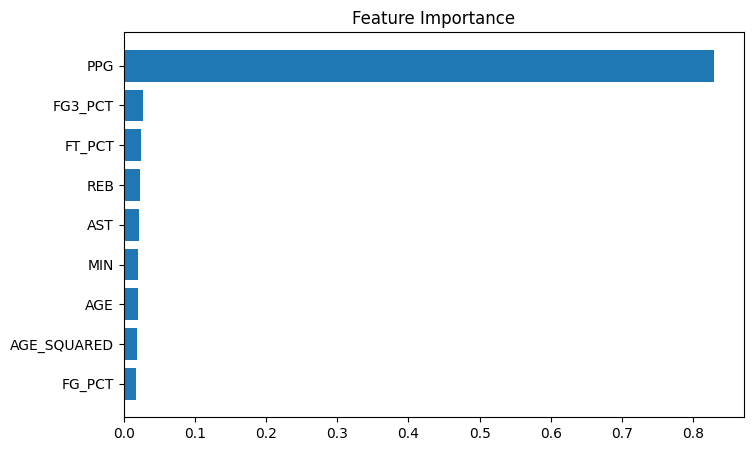

In [508]:
import matplotlib.pyplot as plt

importance = importance.sort_values(
    by='Importance'
)

plt.figure(figsize=(8,5))
plt.barh(
    importance['Feature'],
    importance['Importance']
)
plt.title("Feature Importance")
plt.show()

## Interpreting Feature Importance

Points Per Game (PPG) was by far the most influential predictor, accounting for the majority of the model's decision-making process.

This indicates that a player's correct scoring ability is the strongest indicator of future scoring performances, while factors such as age, shooting percentages, rebounds, and assists play smaller supporting roles.

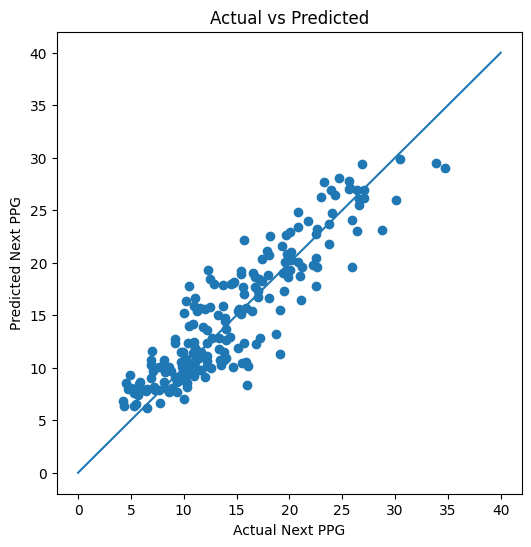

In [509]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_predictions)

plt.xlabel("Actual Next PPG")
plt.ylabel("Predicted Next PPG")
plt.title("Actual vs Predicted")

plt.plot([0,40], [0,40])

plt.show()

In [510]:
results = test.copy()

results["ACTUAL_NEXT_PPG"] = y_test
results["PREDICTED_NEXT_PPG"] = rf_predictions

results["ERROR"] = (results["ACTUAL_NEXT_PPG"] - results["PREDICTED_NEXT_PPG"])

results.sort_values(
    "ERROR",
    ascending=False
)[[
    "PLAYER_NAME",
    "SEASON",
    "PPG",
    "PREDICTED_NEXT_PPG",
    "ACTUAL_NEXT_PPG",
    "ERROR"
]].head(10)

,PLAYER_NAME,SEASON,PPG,PREDICTED_NEXT_PPG,ACTUAL_NEXT_PPG,ERROR
1222,Coby White,2022-23,9.662162,11.289148,19.101266,7.812117
1356,Jalen Johnson,2022-23,5.642857,8.401115,16.000000,7.598885
1657,Tyrese Maxey,2022-23,20.300000,19.549718,25.942857,6.393139
1405,Jonathan Kuminga,2022-23,9.940299,10.196962,16.054054,5.857092
1396,Joel Embiid,2022-23,33.075758,29.004309,34.692308,5.687998
1353,Jalen Brunson,2022-23,24.014706,23.070702,28.727273,5.656570
1227,Collin Sexton,2022-23,14.270833,13.202420,18.692308,5.489887
1607,Shaedon Sharpe,2022-23,9.862500,10.570102,15.937500,5.367398
1279,Donte DiVincenzo,2022-23,9.416667,10.452887,15.543210,5.090323
1370,Jaren Jackson Jr.,2022-23,18.619048,17.745558,22.515152,4.769594


## Largest Posititive Prediction Errors

The table above shows players whose actual next-season scoring averages exceeded the model's predictions by the largest margins.

These cases represent breakout seasons in which players improved much more than historical trends would have suggested.

Such outcomes are difficult for machine learning models to predict beacuse player development is often influenced by factors not captured in the dataset, such as role changes, increased opportunity, or rapid skill improvement.

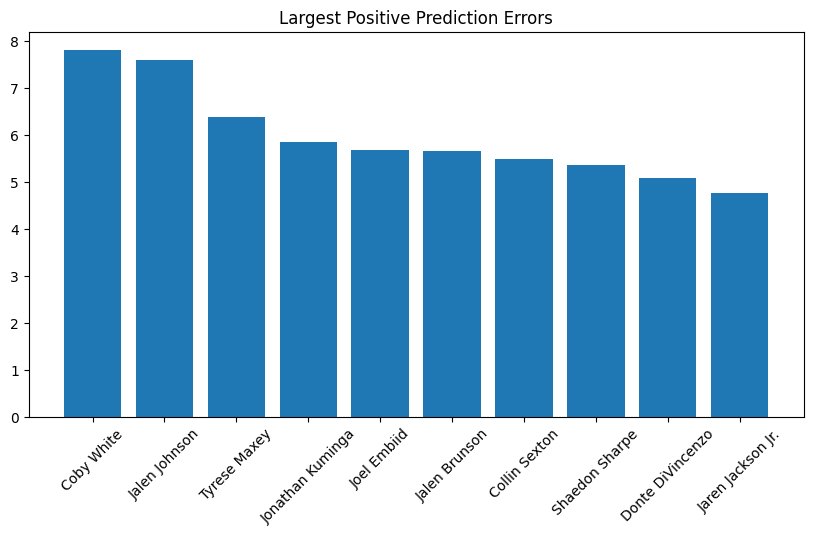

In [511]:
top_errors = results.sort_values("ERROR", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_errors["PLAYER_NAME"], top_errors["ERROR"])
plt.xticks(rotation=45)
plt.title("Largest Positive Prediction Errors")
plt.show()

## Visualizing Breakout Players

The chart highlights the players whose scoring growth was most underestimated by the model.

Many of these players experienced significant increases in usage, playing time, or overall development between seasons.

These examples demonstrate one of the primary limitations of predictive sports models: unexpected player improvement remains difficult to forecasr accurately.

In [512]:
results2 = test.copy()

results2["ACTUAL_NEXT_PPG"] = y_test
results2["PREDICTED_NEXT_PPG"] = rf_predictions

results2["ERROR"] = (results["ACTUAL_NEXT_PPG"] - results["PREDICTED_NEXT_PPG"])

results2.sort_values(
    "ERROR",
    ascending=True
)[[
    "PLAYER_NAME",
    "SEASON",
    "PPG",
    "PREDICTED_NEXT_PPG",
    "ACTUAL_NEXT_PPG",
    "ERROR"
]].head(10)

,PLAYER_NAME,SEASON,PPG,PREDICTED_NEXT_PPG,ACTUAL_NEXT_PPG,ERROR
1613,Spencer Dinwiddie,2022-23,17.329114,17.823747,10.460526,-7.363221
1415,Josh Giddey,2022-23,16.578947,19.266029,12.325000,-6.941029
1440,Keldon Johnson,2022-23,21.984127,22.199252,15.710145,-6.489107
1454,Kevin Huerter,2022-23,15.200000,16.369938,10.234375,-6.135563
1422,Jrue Holiday,2022-23,19.253731,18.488166,12.463768,-6.024398
1594,Russell Westbrook,2022-23,15.876712,16.593092,11.088235,-5.504857
1641,Tre Jones,2022-23,12.867647,15.170162,10.012987,-5.157175
1560,P.J. Washington,2022-23,15.671233,17.982502,12.863014,-5.119488
1668,Wendell Carter Jr.,2022-23,15.228070,15.846893,10.963636,-4.883257
1574,Quentin Grimes,2022-23,11.253521,11.631018,7.039216,-4.591802


## Largest Negative Prediction Errors

The table above shows players whose actual next-season scoring averages
fell significantly below the model's predictions.

These cases represent seasons in which players experienced unexpected
declines in offensive production. Such declines may be caused by
injuries, reduced playing time, changes in team role, aging, or other
factors not captured by the dataset.

Because these external influences are difficult to quantify, they
remain some of the most challenging outcomes for machine learning
models to predict accurately.

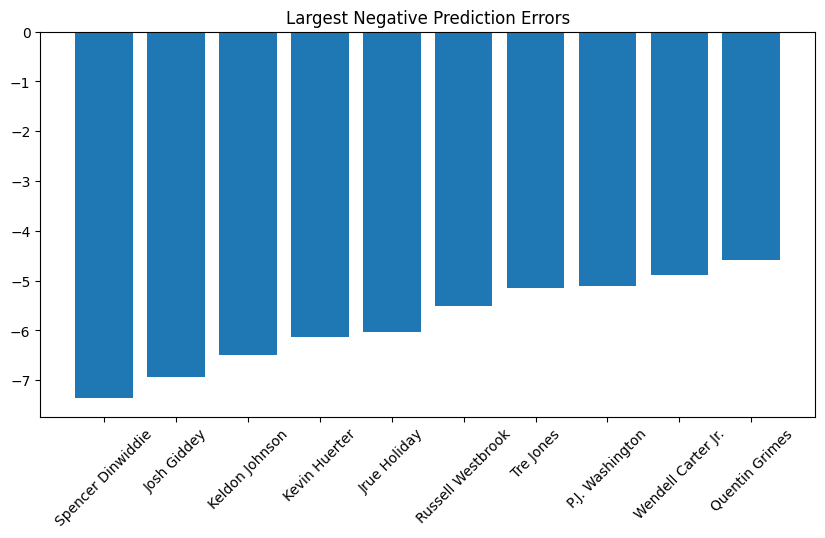

In [513]:
top_errors = results2.sort_values("ERROR", ascending=True).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_errors["PLAYER_NAME"], top_errors["ERROR"])
plt.xticks(rotation=45)
plt.title("Largest Negative Prediction Errors")
plt.show()

## Visualizing Unexpected Declines

The chart highlights players whose future scoring performance was
overestimated by the model.

Many of these players experienced substantial decreases in scoring
production compared to previous seasons. These declines often result
from injuries, roster changes, reduced usage, or age-related regression.

The results illustrate a common limitation of predictive sports
analytics: unexpected declines can be just as difficult to forecast as
breakout seasons.

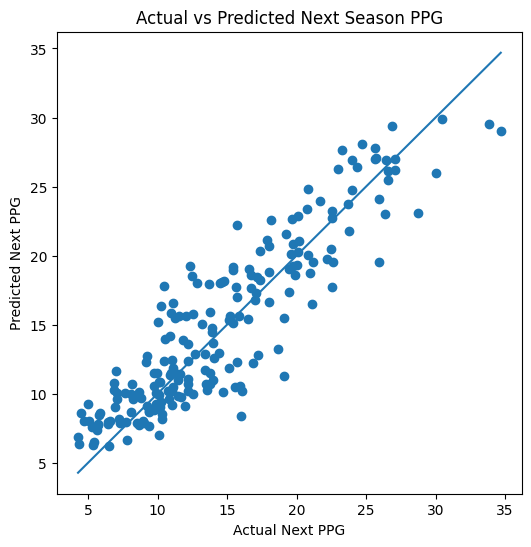

In [514]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Next PPG")
plt.ylabel("Predicted Next PPG")
plt.title("Actual vs Predicted Next Season PPG")

plt.show()

## Actual vs Predicted Scoring Performance

This scatter plot compares the model's predictions with the actual next-season scoring averages.

The diagonal line represents perfect predictions. Points located close to this line indicate accurate forecasts, while points farther away represent larger prediction errors.

Most observations cluster around the diagonal, suggesting that the model successfully captures overall scoring trends across NBA players.